# Medical Recommendation System — Learning Logistic Regression, Random Forest & Gradient Boosting

This notebook is a hands-on way to actually *learn* three classic ML algorithms — **Logistic Regression**, **Random Forest**, and **Gradient Boosting** — by building something concrete: a system that predicts a disease from a list of symptoms, then recommends precautions, medications, diet, and workouts for that disease.

The goal isn't "call `.fit()` three times and compare accuracy." It's to understand *how* each algorithm makes decisions, where they actually differ, and why a dataset can lie to you about how good your model is if you're not careful. You'll hit a `100% accuracy` result early on, and the next two sections are about figuring out why that number can't be trusted — and what the real picture looks like once you fix it.

**Dataset:** 132 binary symptom columns → 41 diseases, plus five lookup tables (description, precautions, medications, diets, workouts) that power the recommendation half of the project. It's a widely-used open dataset across "medicine recommendation system" tutorials, originally derived from a public Kaggle dataset. The notebook downloads everything automatically on first run and caches it locally.

> **Disclaimer:** This is an educational ML project on a public, simplified dataset. It is not a diagnostic tool, and nothing it outputs should be treated as real medical advice.

---
**Roadmap:**
1. Get the data
2. EDA — and a discovery that changes how we evaluate everything after it
3. Logistic Regression, Random Forest, Gradient Boosting — trained and evaluated properly
4. Stress-testing: what actually differs between the three algorithms
5. Hyperparameter tuning (briefly)
6. Wiring a trained model into the recommendation layer
7. Exercises to push this further


In [1]:
import os
import time
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Get the data

Six CSVs, downloaded once and cached in `data/`:
- `Training.csv` — the actual prediction dataset (132 symptoms → disease)
- `description.csv`, `precautions_df.csv`, `medications.csv`, `diets.csv`, `workout_df.csv` — the recommendation lookup tables, keyed by disease name


In [2]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/Priyanshu9898/Medicine-Recommendation-System/main"
FILES = [
    "Training.csv",
    "description.csv",
    "precautions_df.csv",
    "medications.csv",
    "diets.csv",
    "workout_df.csv",
]

for fname in FILES:
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        pd.read_csv(f"{BASE_URL}/{fname}").to_csv(path, index=False)
    print(f"{fname:<20} ready")


Training.csv         ready
description.csv      ready
precautions_df.csv   ready
medications.csv      ready
diets.csv            ready
workout_df.csv       ready


In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, "Training.csv"))
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]  # drop a stray trailing column from the source CSV

print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
df.head()


Shape: (4920, 133)
Missing values: 0


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


## 2. EDA — and a discovery that changes the whole evaluation

Always check class balance before training anything. Medical datasets are usually messy here — some conditions are rare, some are common — and that changes how you should read accuracy later.


41 diseases, 120-120 samples each


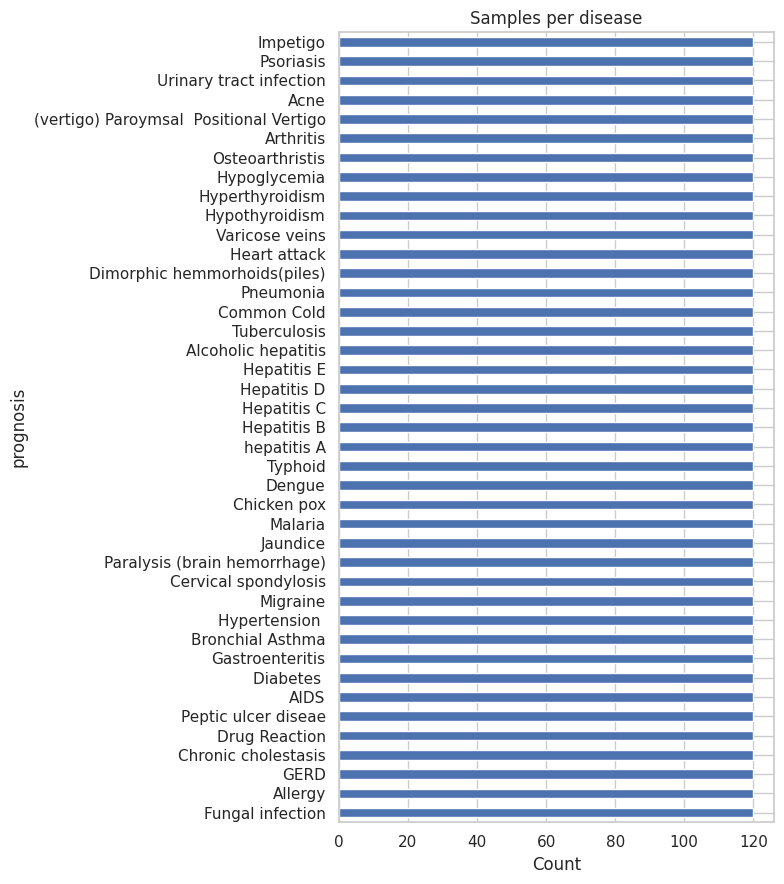

In [4]:
disease_counts = df["prognosis"].value_counts()
print(f"{len(disease_counts)} diseases, {disease_counts.min()}-{disease_counts.max()} samples each")

plt.figure(figsize=(8, 9))
disease_counts.sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Samples per disease")
plt.xlabel("Count")
plt.tight_layout()
plt.show()


Every single disease has **exactly 120 samples**. That's not realistic for real-world medical data (where some conditions are far rarer than others) — it's a sign this dataset was synthetically balanced for teaching purposes. Worth remembering as a limitation, not a property you should expect from data you collect yourself.

Now check something less obvious: how many of the 4,920 rows are actually *unique*.


In [5]:
n_total = len(df)
n_unique = df.drop_duplicates().shape[0]
patterns_per_disease = df.groupby("prognosis").apply(lambda g: g.drop_duplicates().shape[0])

print(f"Total rows: {n_total}")
print(f"Unique rows: {n_unique}")
print(f"Unique symptom patterns per disease: min={patterns_per_disease.min()}, "
      f"mean={patterns_per_disease.mean():.1f}, max={patterns_per_disease.max()}")


Total rows: 4920
Unique rows: 304
Unique symptom patterns per disease: min=5, mean=7.4, max=10


Only **304 unique symptom combinations** exist across all 4,920 rows — about 7 per disease, each one duplicated roughly 16 times. That single fact is going to matter a lot in the next section. Keep it in mind.


## 3. First pass: a plain random train/test split

Standard procedure: encode the labels, split, train all three models, evaluate. Nothing unusual yet.

- **Logistic Regression** — learns one linear weight per symptom per disease and predicts via a softmax over 41 classes. Fast, interpretable, assumes the decision boundary between diseases is roughly linear in symptom-space.
- **Random Forest** — bags many decision trees on bootstrapped samples and random feature subsets, then majority-votes. Each tree overfits a bit differently; averaging cancels out most of that.
- **Gradient Boosting** — builds trees sequentially, each one correcting the errors of the ensemble so far. More expressive, more prone to overfitting if unchecked, and — as you'll see — slower here because it builds one sequence of trees *per class*.


In [6]:
X = df.drop(columns=["prognosis"])
y = df["prognosis"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train_naive, X_test_naive, y_train_naive, y_test_naive = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)

results_naive = {}
for name, model in [
    ("LogReg", LogisticRegression(max_iter=1000)),
    ("RandomForest", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    ("GradBoost", GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)),
]:
    t0 = time.time()
    model.fit(X_train_naive, y_train_naive)
    train_time = time.time() - t0
    preds = model.predict(X_test_naive)
    acc = accuracy_score(y_test_naive, preds)
    results_naive[name] = (train_time, acc)
    print(f"{name:<14} train_time={train_time:6.2f}s   accuracy={acc:.4f}")


LogReg         train_time=  0.16s   accuracy=1.0000


RandomForest   train_time=  0.68s   accuracy=1.0000


GradBoost      train_time= 21.07s   accuracy=1.0000


All three models hit (or nearly hit) **100% accuracy**. That should make you suspicious, not happy — a real medical classification problem essentially never looks like this.

Here's why: with only 304 unique symptom patterns repeated across 4,920 rows, a random split has almost no chance of avoiding duplicates — most test rows are exact duplicates of rows the model already saw in training. The model isn't generalizing, it's recognizing rows it memorized. **This is data leakage**, and it's a real failure mode you'll hit on real projects too, especially with templated or scraped data.

The fix: split by *unique symptom pattern*, not by row, so no pattern appears in both train and test.


## 4. Second pass: a leak-free split

`GroupShuffleSplit` lets us split by a group key — here, the exact symptom combination — guaranteeing no pattern leaks across the train/test boundary. From this point on, `X_train` / `X_test` refer to this leak-free split, and every model in the rest of the notebook is trained and judged against it.


In [7]:
groups = X.astype(str).agg("-".join, axis=1)  # one group id per unique symptom combination

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y_enc, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_enc[train_idx], y_enc[test_idx]

overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f"Train rows: {len(train_idx)}   Test rows: {len(test_idx)}")
print(f"Overlapping symptom patterns between train/test: {len(overlap)}")


Train rows: 3522   Test rows: 1398
Overlapping symptom patterns between train/test: 0


In [8]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "GradBoost": GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    results[name] = {"train_time": train_time, "accuracy": acc, "macro_f1": f1}
    print(f"{name:<14} train_time={train_time:6.2f}s   accuracy={acc:.4f}   macro_f1={f1:.4f}")


LogReg         train_time=  0.10s   accuracy=1.0000   macro_f1=1.0000


RandomForest   train_time=  0.57s   accuracy=1.0000   macro_f1=1.0000


GradBoost      train_time= 17.12s   accuracy=0.9657   macro_f1=0.9091


Now there's an actual difference: **Gradient Boosting drops to ~96.6% / 0.91 macro-F1** on genuinely unseen symptom patterns, while Logistic Regression and Random Forest still hit 100%. Two things worth noting:

- **Training time tells its own story.** Gradient Boosting takes roughly 100-150x longer than the other two here. With 41 classes, sklearn's `GradientBoostingClassifier` effectively trains a one-vs-rest sequence of trees per class — that cost scales with the number of classes in a way Random Forest's parallel, independent trees don't.
- **More powerful ≠ better here.** Gradient Boosting is usually the strongest of the three on messy, real-world tabular data. On *this* dataset, it actually generalizes slightly worse than the simpler models. A good exercise once you're done: tune `learning_rate` and `max_depth` and see if you can close that gap (param search cell further down gives you the pattern to copy).

Let's look at exactly where Gradient Boosting goes wrong.


In [9]:
gb_preds = models["GradBoost"].predict(X_test)
print(classification_report(y_test, gb_preds, target_names=le.classes_, zero_division=0))


                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       0.00      0.00      0.00         6
                                   AIDS       1.00      1.00      1.00        78
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00         6
                                Allergy       1.00      1.00      1.00        12
                              Arthritis       1.00      0.94      0.97       102
                       Bronchial Asthma       1.00      0.93      0.97        90
                   Cervical spondylosis       1.00      1.00      1.00        84
                            Chicken pox       1.00      1.00      1.00         6
                    Chronic cholestasis       1.00      1.00      1.00        12
                            Common Cold       1.00      1.00      1.00        84
                           

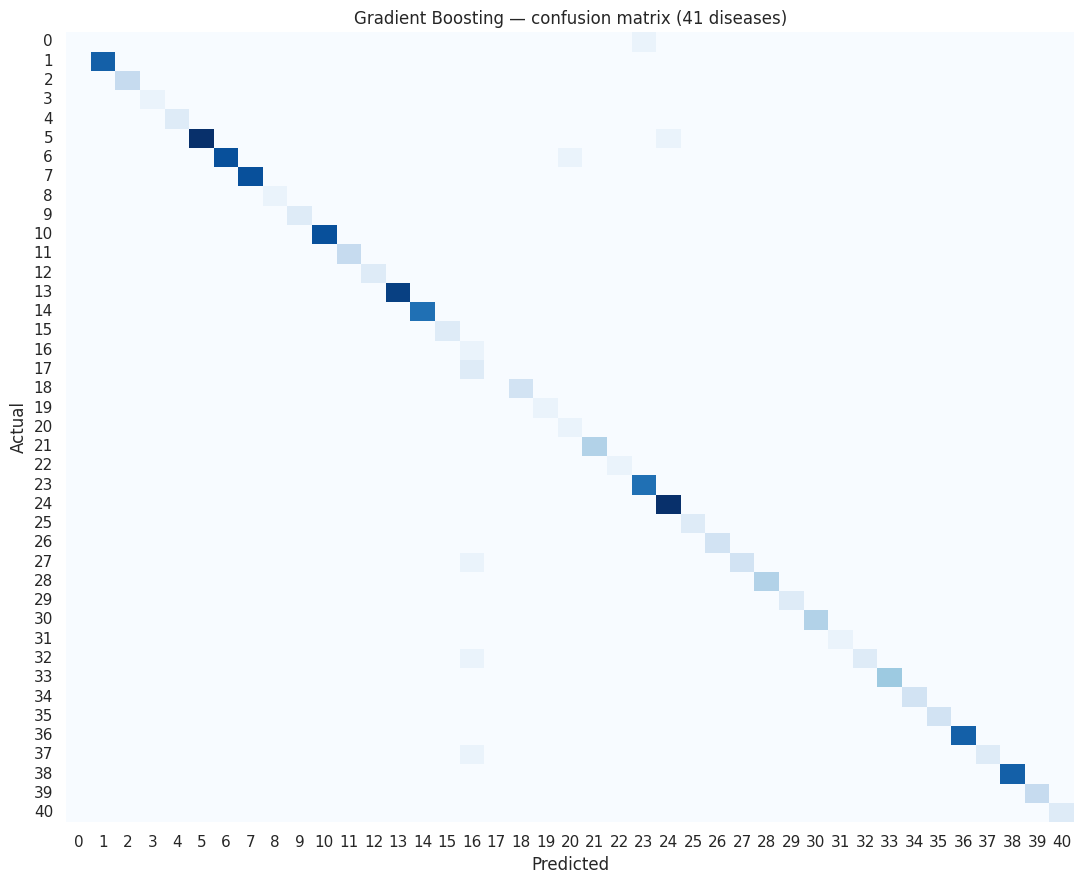

In [10]:
cm = confusion_matrix(y_test, gb_preds)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, cmap="Blues", cbar=False)
plt.title("Gradient Boosting — confusion matrix (41 diseases)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


The off-diagonal cells are where Gradient Boosting confuses one disease for another. With 41 classes this is easier to read as colors than numbers — a clean diagonal line with a handful of stray dots is exactly what "96.6% accuracy with a few systematic confusions" looks like.


## 5. What's actually driving each model's decisions

Random Forest gives you `feature_importances_` directly. For Logistic Regression, averaging `|coefficient|` across all 41 one-vs-rest classes gives a roughly comparable ranking — both are saying "how much does this symptom move the prediction, on average."


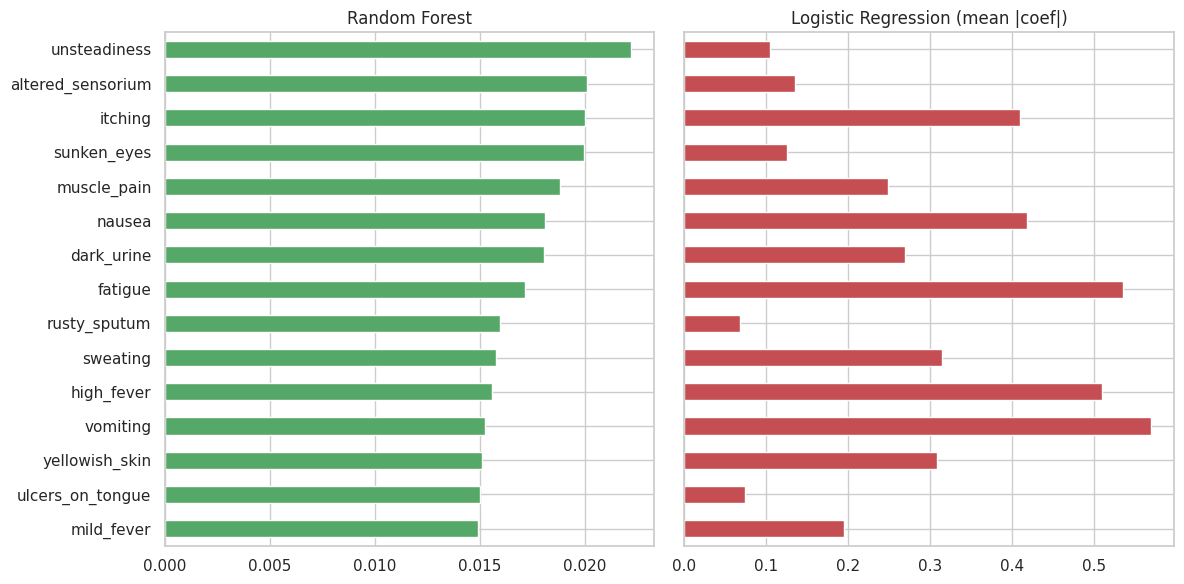

In [11]:
rf_importance = pd.Series(models["RandomForest"].feature_importances_, index=X.columns)
log_importance = pd.Series(np.mean(np.abs(models["LogReg"].coef_), axis=0), index=X.columns)

comparison = pd.DataFrame({
    "RandomForest": rf_importance,
    "LogisticRegression": log_importance,
}).sort_values("RandomForest", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
comparison["RandomForest"].sort_values().plot(kind="barh", ax=axes[0], color="#55A868", title="Random Forest")
comparison["LogisticRegression"].reindex(comparison["RandomForest"].sort_values().index).plot(
    kind="barh", ax=axes[1], color="#C44E52", title="Logistic Regression (mean |coef|)"
)
plt.tight_layout()
plt.show()


If the top symptoms roughly agree between the two rankings, that's a good sign — it means both algorithms are picking up on the same real signal in the data rather than fitting noise in two different, unrelated ways.


## 6. Stress test: noise robustness

Even with the leak fixed, this dataset is still very clean — real patients don't report symptoms with perfect accuracy. Simulate that by randomly flipping a fraction of the binary symptom values in the test set and seeing how each *already-trained* model holds up. No retraining needed here — just re-predicting on corrupted inputs.


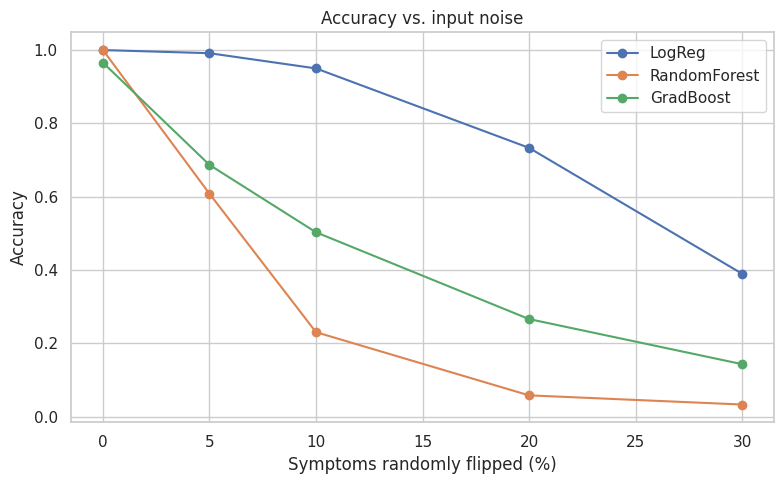

In [12]:
rng = np.random.RandomState(0)

def add_noise(X_arr, flip_frac):
    Xn = np.array(X_arr, copy=True)
    mask = rng.rand(*Xn.shape) < flip_frac
    Xn[mask] = 1 - Xn[mask]
    return Xn

flip_fractions = [0.0, 0.05, 0.10, 0.20, 0.30]
noise_results = {name: [] for name in models}

X_test_arr = X_test.to_numpy()
for frac in flip_fractions:
    X_noisy = add_noise(X_test_arr, frac) if frac > 0 else X_test_arr
    for name, model in models.items():
        acc = accuracy_score(y_test, model.predict(X_noisy))
        noise_results[name].append(acc)

plt.figure(figsize=(8, 5))
for name, accs in noise_results.items():
    plt.plot([f * 100 for f in flip_fractions], accs, marker="o", label=name)
plt.xlabel("Symptoms randomly flipped (%)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. input noise")
plt.legend()
plt.tight_layout()
plt.show()


On this dataset, **Logistic Regression degrades the most gracefully**, while **Random Forest degrades the fastest** — at 10% noise, Logistic Regression is still above 90% while Random Forest has already dropped sharply. That's the opposite of the usual "ensembles are more robust" intuition, and the reason is specific to this data: with only ~132 binary, mostly-independent symptoms and disease boundaries defined by exact symptom subsets, a tree's hard splits ("is this symptom exactly 1 or 0?") can be thrown off entirely by a single flipped bit near the root. A linear model sums weighted evidence across *all* 132 symptoms at once, so a few flipped values barely move the total.

The takeaway isn't "Logistic Regression beats ensembles" as a universal rule — it usually doesn't, especially on noisy real-world tabular data with non-linear interactions. The takeaway is that **robustness depends on how your specific data is structured**, and the only way to know is to actually run the stress test instead of assuming.


## 7. Hyperparameter tuning (briefly)

A quick `RandomizedSearchCV` on Random Forest, using `GroupKFold` so the cross-validation folds respect the same no-leakage rule as the train/test split. The point here is the *workflow* — on a harder dataset this is where you'd actually recover meaningful accuracy gains; here, Random Forest is already near-perfect, so don't expect much movement.


In [13]:
groups_train = groups.iloc[train_idx]

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5, 10],
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=10,
    cv=GroupKFold(n_splits=3),
    scoring="f1_macro",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train, y_train, groups=groups_train)

print("Best params:", search.best_params_)
print("Best CV macro-F1:", round(search.best_score_, 4))
print("Held-out test accuracy:", round(accuracy_score(y_test, search.best_estimator_.predict(X_test)), 4))


Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
Best CV macro-F1: 0.9987
Held-out test accuracy: 1.0


## 8. The recommendation layer

Pick the strongest model from section 4 (highest macro-F1, fastest as a tiebreaker), then wire it up to the five lookup tables: predict a disease, then pull its description, precautions, medications, diet, and workout suggestions.


In [14]:
best_name = max(results, key=lambda n: (round(results[n]["macro_f1"], 4), -results[n]["train_time"]))
best_model = models[best_name]
print(f"Using {best_name} for the recommendation engine "
      f"(macro_f1={results[best_name]['macro_f1']:.4f}, train_time={results[best_name]['train_time']:.2f}s)")


Using LogReg for the recommendation engine (macro_f1=1.0000, train_time=0.10s)


In [15]:
description_df = pd.read_csv(os.path.join(DATA_DIR, "description.csv"))
precautions_df = pd.read_csv(os.path.join(DATA_DIR, "precautions_df.csv"))
medications_df = pd.read_csv(os.path.join(DATA_DIR, "medications.csv"))
diets_df = pd.read_csv(os.path.join(DATA_DIR, "diets.csv"))
workout_df = pd.read_csv(os.path.join(DATA_DIR, "workout_df.csv"))

FEATURE_COLUMNS = X.columns.tolist()


def get_recommendations(disease):
    desc_match = description_df.loc[description_df["Disease"] == disease, "Description"]
    description = desc_match.values[0] if len(desc_match) else "No description available."

    prec_match = precautions_df.loc[precautions_df["Disease"] == disease]
    precautions = []
    if len(prec_match):
        row = prec_match.iloc[0][["Precaution_1", "Precaution_2", "Precaution_3", "Precaution_4"]]
        precautions = [p for p in row.tolist() if pd.notna(p)]

    med_match = medications_df.loc[medications_df["Disease"] == disease, "Medication"]
    medications = ast.literal_eval(med_match.values[0]) if len(med_match) else []

    diet_match = diets_df.loc[diets_df["Disease"] == disease, "Diet"]
    diet = ast.literal_eval(diet_match.values[0]) if len(diet_match) else []

    workouts = workout_df.loc[workout_df["disease"] == disease, "workout"].tolist()

    return {
        "disease": disease,
        "description": description,
        "precautions": precautions,
        "medications": medications,
        "diet": diet,
        "workout": workouts,
    }


def predict_disease(symptom_list, model=best_model):
    input_vector = pd.DataFrame(np.zeros((1, len(FEATURE_COLUMNS))), columns=FEATURE_COLUMNS)
    unrecognized = []
    for s in symptom_list:
        s_clean = s.strip().lower().replace(" ", "_")
        if s_clean in FEATURE_COLUMNS:
            input_vector[s_clean] = 1
        else:
            unrecognized.append(s)

    if unrecognized:
        print(f"Not recognized, ignored: {unrecognized}")

    pred_encoded = model.predict(input_vector)[0]
    return le.inverse_transform([pred_encoded])[0]


def explain(symptom_list, model=best_model):
    disease = predict_disease(symptom_list, model)
    rec = get_recommendations(disease)

    print(f"Predicted disease: {rec['disease']}\n")
    print(f"Description: {rec['description']}\n")
    print("Precautions:")
    for p in rec["precautions"]:
        print(f"  - {p}")
    print("\nMedications:")
    for m in rec["medications"]:
        print(f"  - {m}")
    print("\nDiet:")
    for d in rec["diet"]:
        print(f"  - {d}")
    print("\nWorkout:")
    for w in rec["workout"][:5]:
        print(f"  - {w}")


Try it with a few symptoms. `FEATURE_COLUMNS` (printed above) has the exact symptom names this model was trained on — `predict_disease` will warn you about any name it doesn't recognize instead of failing silently.


In [16]:
explain(["itching", "skin_rash", "nodal_skin_eruptions"])


Predicted disease: Fungal infection

Description: Fungal infection is a common skin condition caused by fungi.

Precautions:
  - bath twice
  - use detol or neem in bathing water
  - keep infected area dry
  - use clean cloths

Medications:
  - Antifungal Cream
  - Fluconazole
  - Terbinafine
  - Clotrimazole
  - Ketoconazole

Diet:
  - Antifungal Diet
  - Probiotics
  - Garlic
  - Coconut oil
  - Turmeric

Workout:
  - Avoid sugary foods
  - Consume probiotics
  - Increase intake of garlic
  - Include yogurt in diet
  - Limit processed foods


In [17]:
explain(["high_fever", "headache", "nausea", "vomiting"])


Predicted disease: Malaria

Description: Malaria is a mosquito-borne infectious disease affecting humans and other animals.

Precautions:
  - Consult nearest hospital
  - avoid oily food
  - avoid non veg food
  - keep mosquitos out

Medications:
  - Antimalarial drugs
  - Antipyretics
  - Antiemetic drugs
  - IV fluids
  - Blood transfusions

Diet:
  - Malaria Diet
  - Hydration
  - High-Calorie Diet
  - Soft and bland foods
  - Oral rehydration solutions

Workout:
  - Stay hydrated
  - Consume nutrient-rich foods
  - Include protein-rich foods
  - Consume foods rich in antioxidants
  - Limit fatty and greasy foods


## 9. Where to take this next

A few directions worth exploring once the above makes sense:

- **Close the Gradient Boosting gap.** Tune `learning_rate` (try 0.05-0.3) and `max_depth` (try 2-5) and see whether it can match Logistic Regression / Random Forest on the leak-free test set.
- **Try `XGBoost` or `LightGBM`.** Same boosting idea as `GradientBoostingClassifier`, but built for speed — useful to compare wall-clock training time on this exact dataset.
- **Add SHAP.** `pip install shap` and run it against the Random Forest model — much richer per-prediction explanations than `feature_importances_` alone.
- **Calibrate probabilities.** `model.predict_proba()` gives you confidence scores — check with `sklearn.calibration.calibration_curve` whether "90% confident" actually means right 90% of the time, especially for Gradient Boosting after the leak fix.
- **Wrap it as an API.** A FastAPI endpoint that takes a symptom list and returns this notebook's `explain()` output as JSON is a small, natural next step.
- **Find a noisier dataset.** This one is synthetically clean by design. A real-world symptom-checker dataset (with missing values, ambiguous labels, class imbalance) will make all three algorithms behave very differently from what you saw here — and that's where the real learning is.
